In [1]:
# Import the custom analysis module with forced reload
import importlib
import sys

# Remove from cache if it exists and force reload
if 'lp_analysis' in sys.modules:
    del sys.modules['lp_analysis']

# Fresh import
from lp_analysis import (
    AssetPair, PriceRange, LPConfig,
    LPCalculator, LPAnalyzer, LPVisualizer
)

from lp_analysis import (
    AssetPair, PriceRange, LeveragedLPConfig, DebtAsset,
    LeveragedLPCalculator, LPAnalyzer, RiskAnalyzer, LPVisualizer,
    ExposureAnalyzer, ExposureVisualizer
)

print("✓ Module reloaded with exposure analysis functionality!")

✓ Module reloaded with exposure analysis functionality!


Initial Position:
  ETH: 0.980194
  USDC: 5099.03
  Liquidity: 3569.13
Max Gain: $97.06
Max Loss: $-905.37


/Users/mesfahani1/myProjects/project_defi_analyzer/lp_analysis/visualization/plots.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


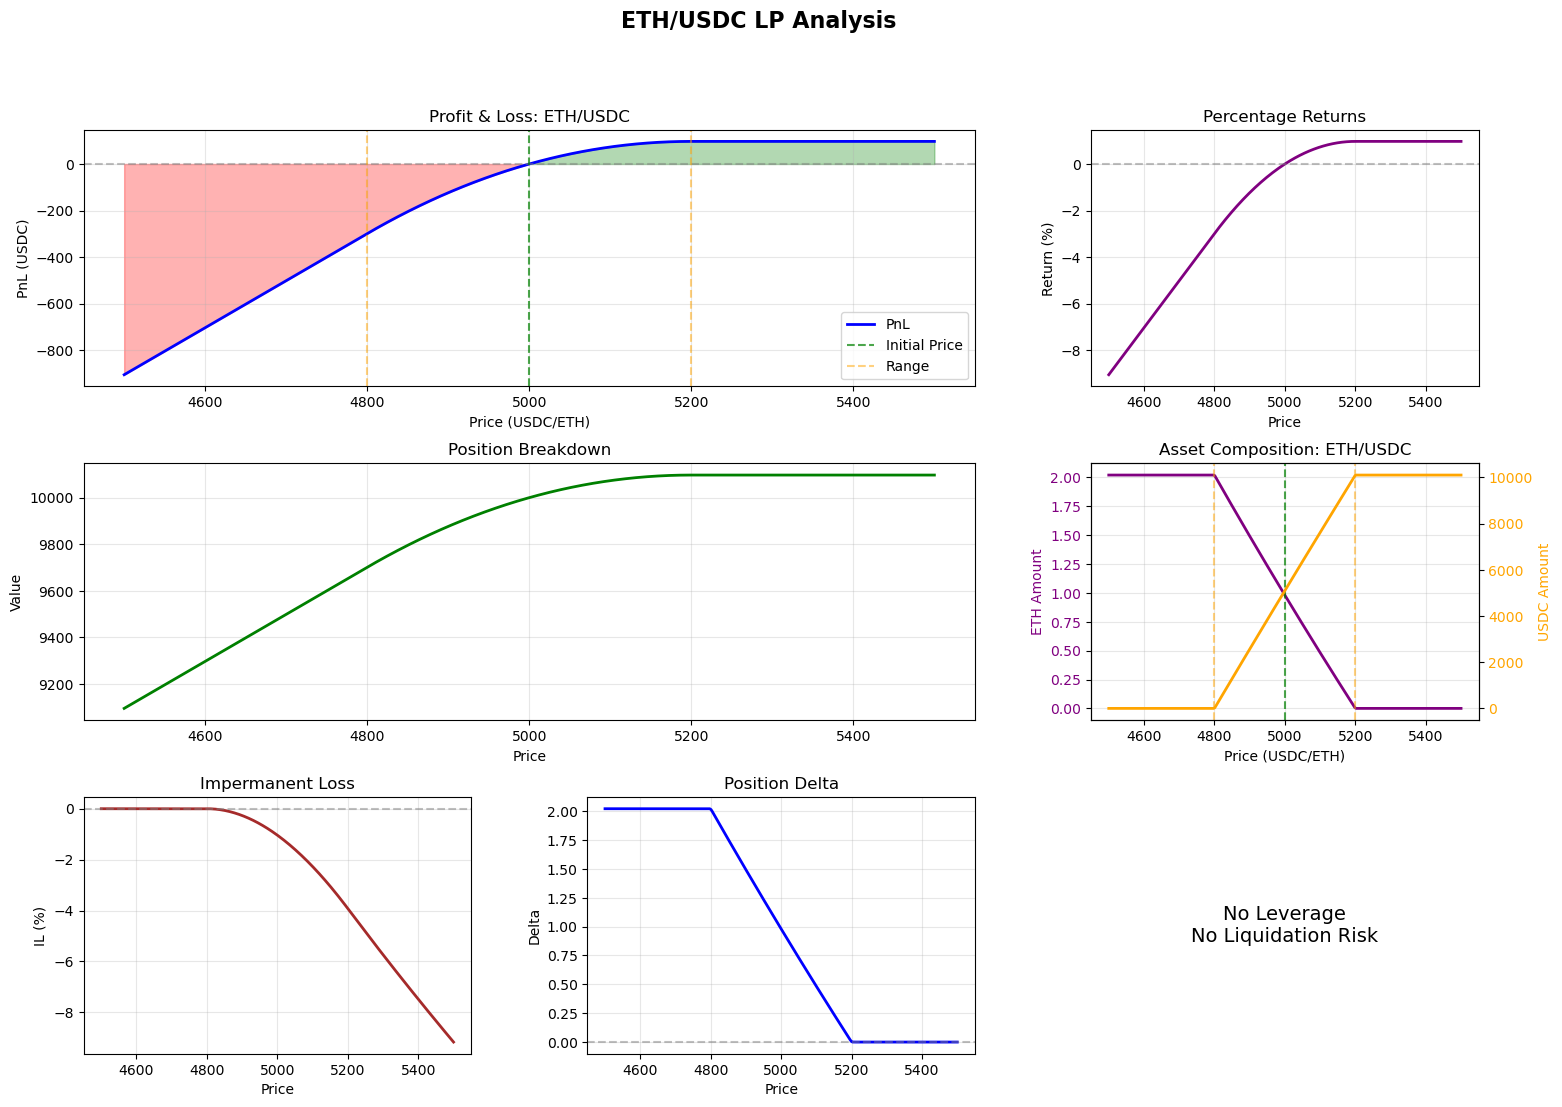

In [2]:

# Cell 2: Configure LP
config = LPConfig(
    capital_asset1=10000,  # $10k USDC
    price_initial=5000,    # $5000/ETH
    price_range=PriceRange(4800, 5200),
    assets=AssetPair("ETH", "USDC"),
    fee_tier=0.3
)

# Cell 3: Calculate
calc = LPCalculator()
initial_pos = calc.calculate_initial_position(config)

print(f"Initial Position:")
print(f"  ETH: {initial_pos.amount0:.6f}")
print(f"  USDC: {initial_pos.amount1:.2f}")
print(f"  Liquidity: {initial_pos.liquidity:.2f}")

# Cell 4: Simulate

result = LeveragedLPCalculator().simulate_price_range(
    config, price_min=4500, price_max=5500
)

# Cell 5: Analyze
result = LPAnalyzer.analyze_simulation(result)

print(f"Max Gain: ${result.metrics['pnl']['max_gain']:.2f}")
print(f"Max Loss: ${result.metrics['pnl']['max_loss']:.2f}")

# Cell 6: Visualize
LPVisualizer.plot_comprehensive_dashboard(result)

Leveraged LP: ETH/USDC @ 6.0x
Liquidation Range: [3840.00, 4851.37]
Daily Cost: $27.40
VaR (95%): $-11980.35


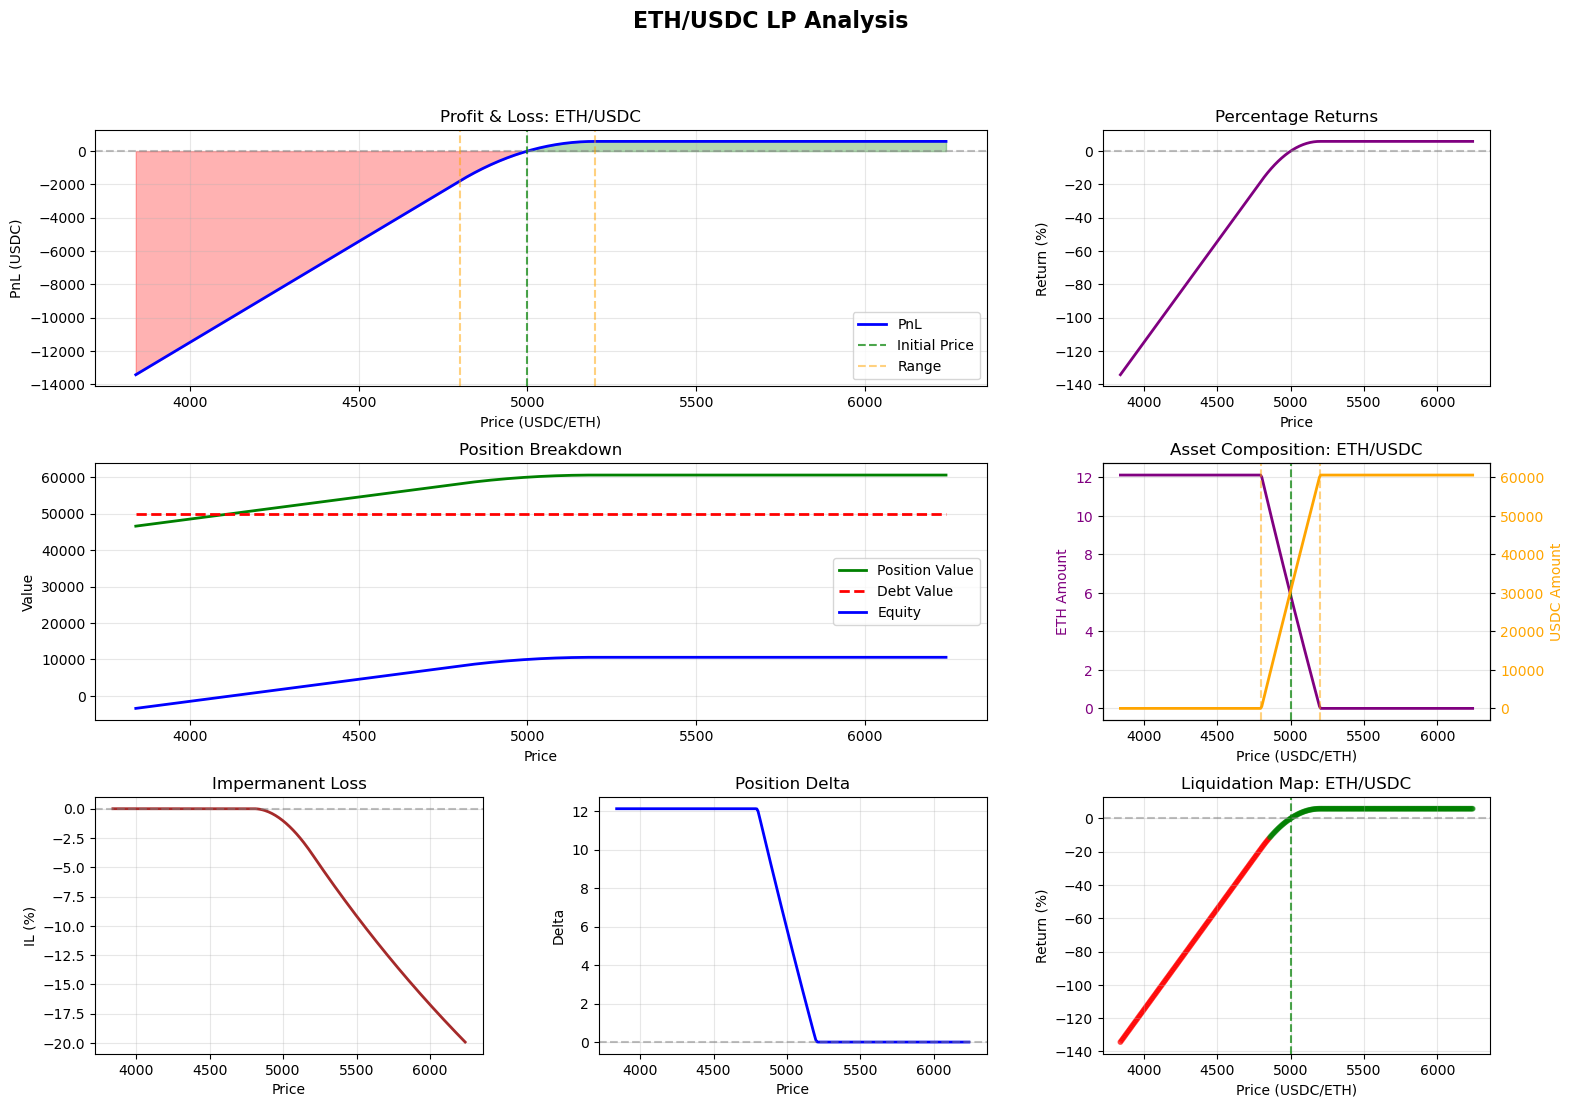

In [3]:

# Cell 2: Configure Leveraged LP
config = LeveragedLPConfig(
    capital_asset1=10000,
    price_initial=5000,
    price_range=PriceRange(4800, 5200),
    assets=AssetPair("ETH", "USDC"),
    leverage=6.0,
    debt_asset=DebtAsset.ASSET1,  # Borrow USDC
    borrow_apr=20.0,
    max_ltv=0.8,
    liquidation_threshold=0.85
)

# Cell 3: Simulate
calc = LeveragedLPCalculator()
result = calc.simulate_price_range(config)

# Cell 4: Analyze
result = LPAnalyzer.analyze_simulation(result)
result.metrics['risk'] = RiskAnalyzer.analyze_risk(result)

# Cell 5: Print Summary
liq = result.metrics['risk']['liquidation_prices']
print(f"Leveraged LP: {config.assets} @ {config.leverage}x")
if liq['lower'] is not None:
    print(f"Liquidation Range: [{liq['lower']:.2f}, {liq['upper']:.2f}]")
else:
    print(f"Liquidation Range: No liquidation in simulated range")
print(f"Daily Cost: ${result.metrics['risk']['daily_cost']:.2f}")
if result.metrics['risk']['var_95'] is not None:
    print(f"VaR (95%): ${result.metrics['risk']['var_95']:.2f}")

# Cell 6: Visualize
LPVisualizer.plot_comprehensive_dashboard(result)


# Exposure Analysis for Leveraged LPs

This section demonstrates how to analyze asset exposure for leveraged liquidity positions.

**Key Concepts:**
- **Net Exposure** = LP Holdings - Debt
- **USDC Debt** → Long ETH exposure (hold ETH, owe stable)
- **ETH Debt** → Short ETH exposure (hold stable, owe ETH)

Use this to optimize exposure to volatile assets in high-leverage strategies.

In [4]:
# Example 1: Single Position Exposure Analysis

# Create two positions: one with USDC debt, one with ETH debt
config_usdc_debt = LeveragedLPConfig(
    capital_asset1=10000,
    price_initial=5000,
    price_range=PriceRange(4800, 5200),
    assets=AssetPair("ETH", "USDC"),
    leverage=5.0,
    debt_asset=DebtAsset.ASSET1,  # Borrow USDC → Long ETH
    borrow_apr=10.0,
)

config_eth_debt = LeveragedLPConfig(
    capital_asset1=10000,
    price_initial=5000,
    price_range=PriceRange(4800, 5200),
    assets=AssetPair("ETH", "USDC"),
    leverage=5.0,
    debt_asset=DebtAsset.ASSET0,  # Borrow ETH → Short ETH
    borrow_apr=15.0,
)

# Simulate both
calc = LeveragedLPCalculator()
result_usdc = calc.simulate_price_range(config_usdc_debt)
result_eth = calc.simulate_price_range(config_eth_debt)

# Analyze with exposure
result_usdc = LPAnalyzer.analyze_simulation(result_usdc)
result_usdc = ExposureAnalyzer.analyze_exposure(result_usdc)

result_eth = LPAnalyzer.analyze_simulation(result_eth)
result_eth = ExposureAnalyzer.analyze_exposure(result_eth)

# Display exposure at initial price
print("="*70)
print("EXPOSURE COMPARISON AT INITIAL PRICE")
print("="*70)

exp_usdc = result_usdc.metrics['exposure_profile']
exp_eth = result_eth.metrics['exposure_profile']

mid_idx = len(result_usdc.prices) // 2

print(f"\n💰 USDC Debt (Long ETH Exposure):")
print(f"  Net ETH: {exp_usdc['asset0_net_tokens'][mid_idx]:.6f} tokens")
print(f"  Net USDC: ${exp_usdc['asset1_net_tokens'][mid_idx]:.2f}")
print(f"  ETH Exposure: {exp_usdc['asset0_exposure_pct'][mid_idx]:.1f}%")
print(f"  USDC Exposure: {exp_usdc['asset1_exposure_pct'][mid_idx]:.1f}%")

print(f"\n📉 ETH Debt (Short ETH Exposure):")
print(f"  Net ETH: {exp_eth['asset0_net_tokens'][mid_idx]:.6f} tokens")
print(f"  Net USDC: ${exp_eth['asset1_net_tokens'][mid_idx]:.2f}")
print(f"  ETH Exposure: {exp_eth['asset0_exposure_pct'][mid_idx]:.1f}%")
print(f"  USDC Exposure: {exp_eth['asset1_exposure_pct'][mid_idx]:.1f}%")

print("\n" + "="*70)


EXPOSURE COMPARISON AT INITIAL PRICE

💰 USDC Debt (Long ETH Exposure):
  Net ETH: 3.797459 tokens
  Net USDC: $-8963.06
  ETH Exposure: 187.9%
  USDC Exposure: -87.9%

📉 ETH Debt (Short ETH Exposure):
  Net ETH: -4.202541 tokens
  Net USDC: $31036.94
  ETH Exposure: -215.4%
  USDC Exposure: 315.4%



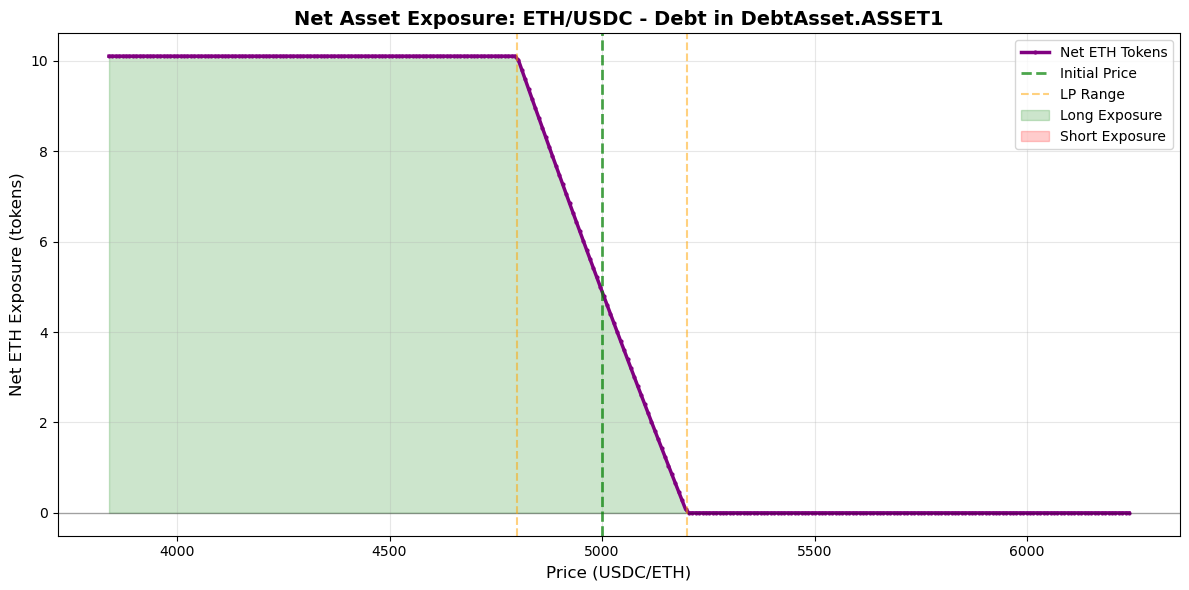

<Axes: title={'center': 'Net Asset Exposure: ETH/USDC - Debt in DebtAsset.ASSET1'}, xlabel='Price (USDC/ETH)', ylabel='Net ETH Exposure (tokens)'>

In [5]:
# Example 2: Visualize Net Exposure

# Plot net token exposure for USDC debt position
ExposureVisualizer.plot_net_exposure(result_usdc)


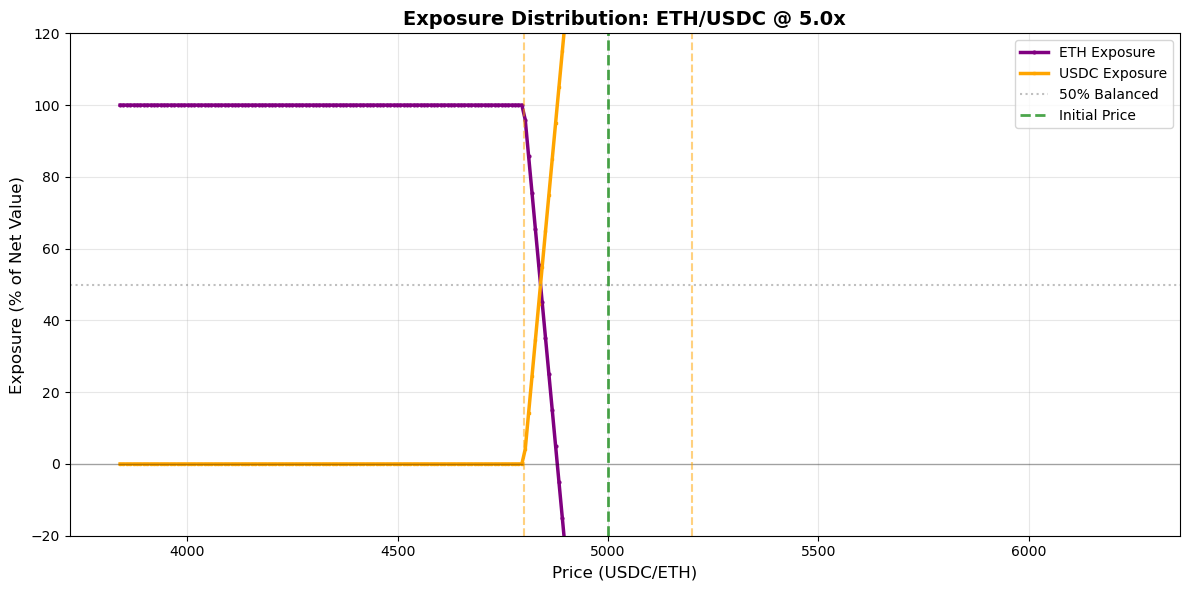

<Axes: title={'center': 'Exposure Distribution: ETH/USDC @ 5.0x'}, xlabel='Price (USDC/ETH)', ylabel='Exposure (% of Net Value)'>

In [6]:
# Example 3: Visualize Exposure Percentages

# Plot exposure distribution for ETH debt position  
ExposureVisualizer.plot_exposure_percentage(result_eth)


/Users/mesfahani1/myProjects/project_defi_analyzer/lp_analysis/visualization/plots.py:479: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


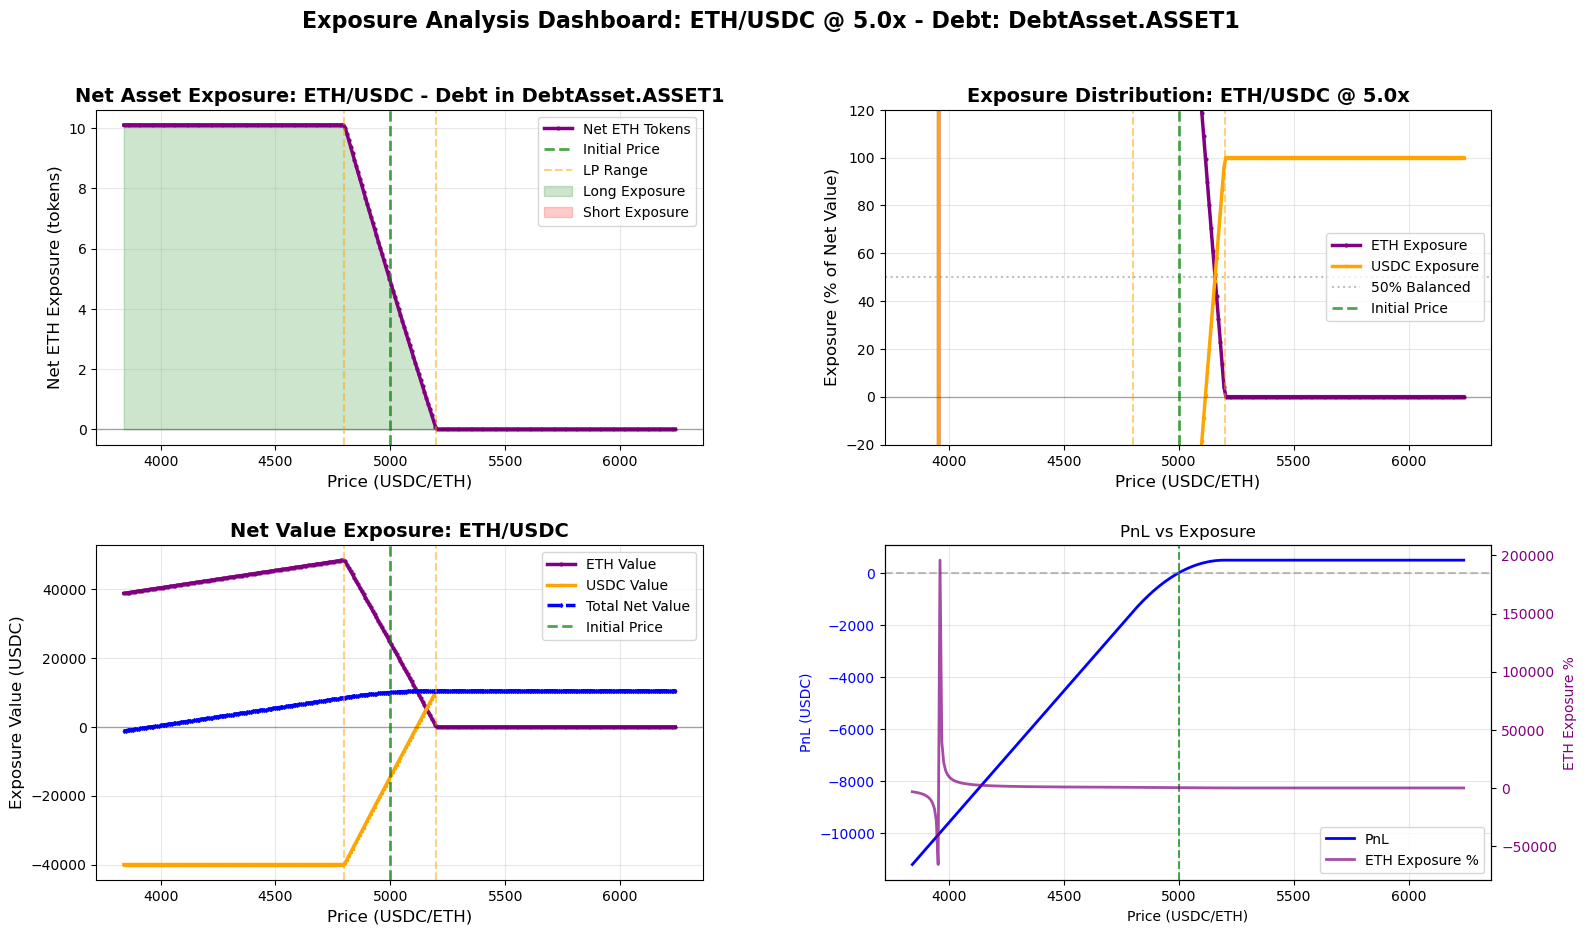

In [7]:
# Example 4: Complete Exposure Dashboard

# Comprehensive dashboard for USDC debt position
ExposureVisualizer.plot_exposure_dashboard(result_usdc)


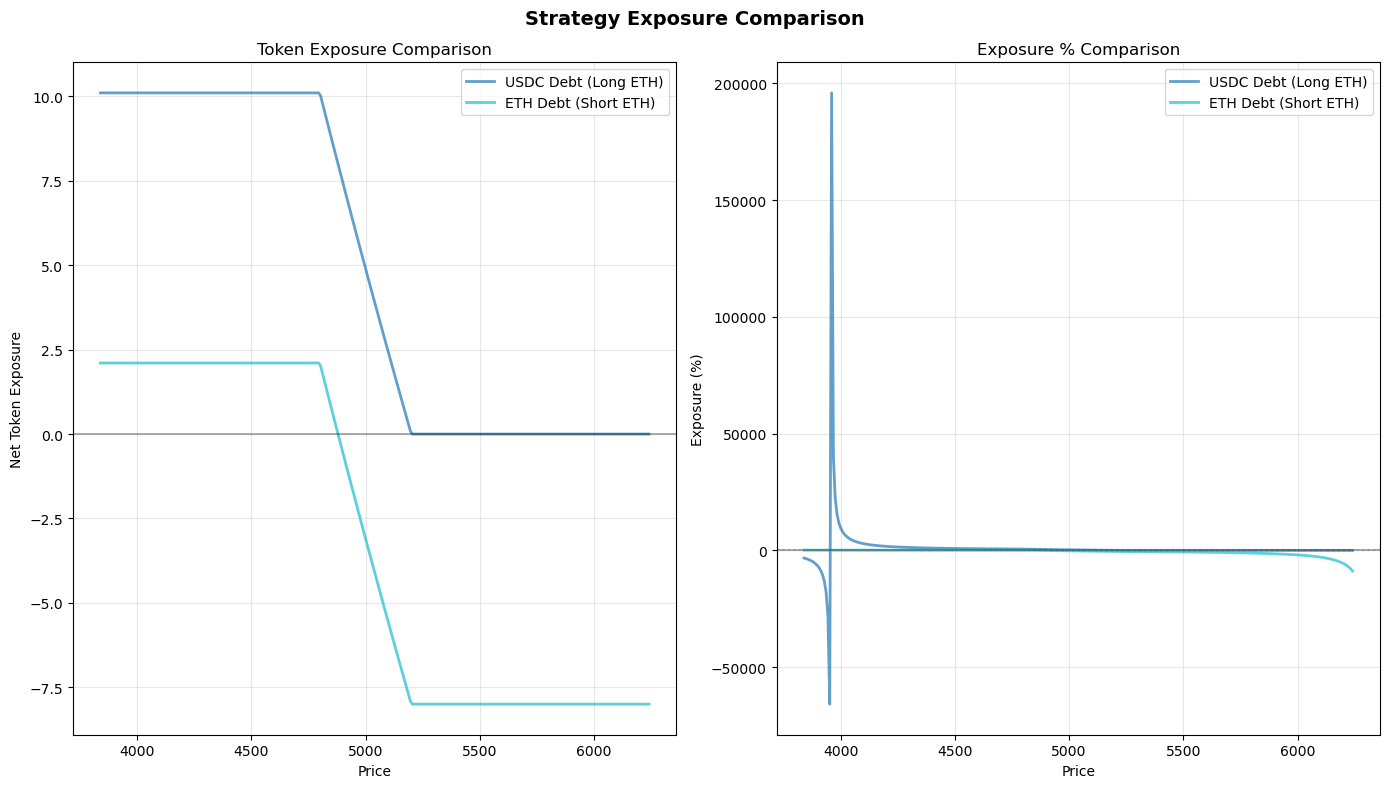


STRATEGY COMPARISON SUMMARY

ETH/USDC - 5.0x - Debt: DebtAsset.ASSET1
  Initial ETH Exposure: 239.9%
  Average ETH Exposure: 910.1%
  Exposure Stability (σ): 12524.76%

ETH/USDC - 5.0x - Debt: DebtAsset.ASSET0
  Initial ETH Exposure: -160.2%
  Average ETH Exposure: -681.0%
  Exposure Stability (σ): 1317.35%


In [8]:
# Example 5: Compare Multiple Strategies

# Compare exposure profiles side-by-side
ExposureVisualizer.compare_exposure_strategies(
    [result_usdc, result_eth],
    labels=['USDC Debt (Long ETH)', 'ETH Debt (Short ETH)']
)

# Detailed comparison metrics
comparison = ExposureAnalyzer.compare_exposure_strategies([result_usdc, result_eth])

print("\n" + "="*70)
print("STRATEGY COMPARISON SUMMARY")
print("="*70)

for strat in comparison['strategies']:
    print(f"\n{strat['name']} - {strat['leverage']}x - Debt: {strat['debt_asset']}")
    print(f"  Initial {strat['name'].split('/')[0]} Exposure: {strat['initial_asset0_exposure_pct']:.1f}%")
    print(f"  Average {strat['name'].split('/')[0]} Exposure: {strat['avg_asset0_exposure_pct']:.1f}%")
    print(f"  Exposure Stability (σ): {strat['exposure_stability']:.2f}%")
